<a href="https://colab.research.google.com/github/SandiFerdiyansyah/Analisis-aplikasi-pemerintahan-Sentuh-Tanahku/blob/main/Sandi%20Ferdiyansyah_14022300003_aplikasi_pemerintahan_Sentuh_Tanahku_BPN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.3 MB/s eta 0:00:00


Analisis aplikasi pemerintahan Sentuh Tanahku BPN

1.   List item
2.   List item



In [3]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'id.go.bpn.sentuh',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=1000,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 1000 ulasan ke 'ulasan_google_play.csv'


In [4]:
pip install transformers torch pandas

Analisis Sentimen Menggunakan Indo-RoBERTa

In [5]:
import pandas as pd
from transformers import pipeline

# Muat data dari file CSV yang sudah dibuat sebelumnya
df = pd.read_csv('/content/ulasan_google_play.csv')

# Inisialisasi pipeline sentiment analysis dengan model Indo-RoBERTa
# Model ini mengklasifikasikan teks ke dalam 3 label: Positive, Neutral, Negative
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

def get_sentiment(text):
    try:
        # Batasi teks agar tidak melebihi kapasitas model (biasanya 512 token)
        result = sentiment_pipeline(str(text)[:512])[0]
        return result['label'], result['score']
    except:
        return "Error", 0.0

# Jalankan analisis (ini mungkin memakan waktu beberapa menit tergantung jumlah data)
print("Sedang memproses sentimen...")
df[['label', 'confidence']] = df['content'].apply(lambda x: pd.Series(get_sentiment(x)))

# Tampilkan hasil
display(df.head())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Sedang memproses sentimen...


,userName,score,at,content,label,confidence
0,Ilyas Ssos,5,2026-04-30 01:42:53,baguss,positive,0.564042
1,stefanus hariyanto,5,2026-04-30 01:09:19,sangat membantu,positive,0.982804
2,Pecinta Alam,5,2026-04-29 23:52:29,sangat bermanfaat,positive,0.984979
3,Bang Ujang,4,2026-04-29 23:22:42,membantu,negative,0.487503
4,Aris Sikac,5,2026-04-29 23:13:32,sangat bermanfaat dn memudahkan,positive,0.994985


In [7]:
# Ringkasan Statistik Sentimen
print("Ringkasan Sentimen:")
print(df['label'].value_counts())

# Simpan hasil analisis ke CSV baru
df.to_csv('ulasan_google_play_analyzed.csv', index=False)
print("\nHasil analisis disimpan ke 'ulasan_google_play_analyzed.csv'")

Ringkasan Sentimen:
label
positive    652
negative    239
neutral     109
Name: count, dtype: int64

Hasil analisis disimpan ke 'ulasan_google_play_analyzed.csv'


Visualisasi Hasil Analisis Sentimen

/tmp/ipykernel_4441/4270212602.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis', ax=ax[0])


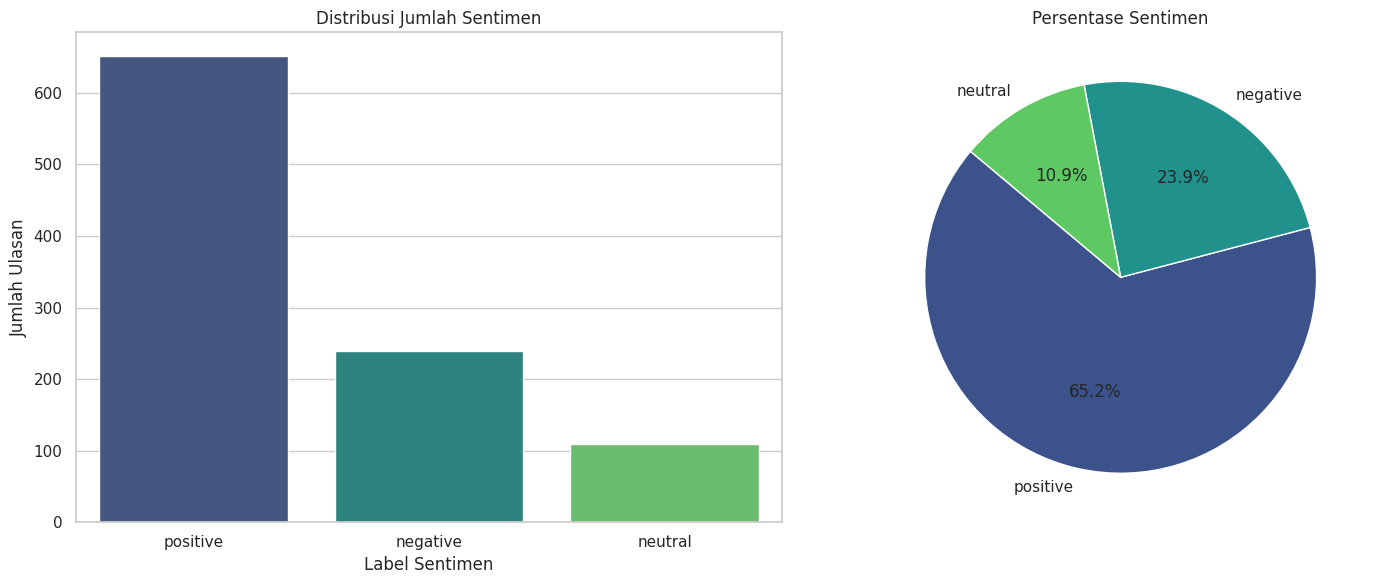

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set(style="whitegrid")

# Membuat figure dengan dua subplot
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar Chart: Distribusi Jumlah Sentimen
sns.countplot(x='label', data=df, palette='viridis', ax=ax[0])
ax[0].set_title('Distribusi Jumlah Sentimen')
ax[0].set_xlabel('Label Sentimen')
ax[0].set_ylabel('Jumlah Ulasan')

# 2. Pie Chart: Persentase Sentimen
sentiment_counts = df['label'].value_counts()
ax[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(sentiment_counts)))
ax[1].set_title('Persentase Sentimen')

plt.tight_layout()
plt.show()

### Daftar Ulasan Negatif Panjang (20+ Kata)

Berikut adalah ulasan negatif mendetail yang dapat digunakan untuk menganalisis kesalahan atau masalah pada aplikasi.

In [15]:
# Menampilkan ulasan negatif yang memiliki 20 kata atau lebih secara utuh
long_negative_reviews = df[(df['label'] == 'negative') & (df['content'].str.split().str.len() >= 20)][['userName', 'content']]

pd.set_option('display.max_colwidth', None)

print(f"Menampilkan {len(long_negative_reviews)} ulasan negatif mendetail:")
display(long_negative_reviews)

Menampilkan 35 ulasan negatif mendetail:


,userName,content
133,Momoy Cat,"ini apk gunanya apa coba, gak jelas bgt. Status berkas sudah selesai bisa diambil, faktanya belom kelar juga, aneh bgt. Klo by sistem harusnya ya jgn ngeprank dong, perbaiki SDM nya , kerja yg bener , udah gak sesuai estimasi , eh ngeprank pula!"
184,Naufal Fadillah,sweaar Ribet bangeet ngurus Cek sertifikat rmh alasannya arsip surat tanah tdk ditemukan ... yg heran kok bs didalam gedung BPN arsip surat tanah bs hilang mang tuh surat tanah bs jalan sendiri yach ??? ini sdh hampir 3 bln lebih blm ditemukan & sy mau ngurus penerbitan surat tanah baru jg dipersulit padahal sy butuh utk pencairan dana KPR bank ... benar2 kecewaaaaaaaaa
240,NLC,"cek lahan susah memuat data mulu, udah di un instal juga masih sama, jaringan gak ada masalah buang waktu sekali"
281,Teuku Helmi,"disistem sertifikat sudah selesai dan keterangan sudah diambil sejak 2 minggu lalu, namun saya baru sempat datang ke BPN hari ini, tapi penjelasan dari petugas di BPan belum siap sertifikatnya, itu untuk sistem aja biar layanan tidak kadaluarsa."
331,Mas bro channel,apk sudah bgs cuman bertanya lewat email tidak ada respon dan lewat wa mlh bot yg jawab.pelayanan digital di email dan wa yg kurang memuaskan...sudah 1x24 jam lebihnya buanyak...poll
332,IRWAN Setyo Budi,"kok bisa ya, tiba2 punya sertifikat di aplikasi, trus mau konfirmasi di kantor atr BPN GK ada kejelasan,udah nunggu di kantor 6 jam, terus di suruh pulang , ngurus di desa lagi katanya..., sampai rumah, cek aplikasi sertifikat tiba2 hilang lagi...😮‍💨😮‍💨😮‍💨, di peta juga tiba2 kosong, sebelumnya ada hak milik,,kayak di permainkan,,, mau lapor,GK tau kemana,,,"
350,Arnoll Arnoll,"tiap taun rubah/geser garis kuning nya, ini aplikasi kayaknya gak bisa buat patokan buat penentuan batas tanah kita, aku ada buktinya gak cuman omong doang"
356,Maxy Ida Marwati,"saya ingin mengecek tanah mbah saya yg belum dbuat sertifikat, namun d aplikasi wajib mengisi nomor sertifikat ini sih yang agak sulit. ujung2nya harus ke BPN juga, pdhal cuma lagi survey aja apakah tanah ini sudah ada sertifikatnya apa blm"
359,Haktarezeki Betayusni,"sertifikat elektronik telah diterima. salinan asli SHM Hak Milik (dari hasil pemecahan dari bidang hak guna bangunan/perubahan hak) dan PPAT dan NIB tertera. NAMUN SANGAT DISESALKAN ; saat dicek Nib di aplikasi Sentuh Tanahku, malah yang ada hak guna bangunan di kolom abu abu, seharusnya dikolom kuning. ya di update lah. yang lalai dimana, apa BPN nya, atau notaris atau aplikasi sentuh tanahku. mendingan aplikasi ini ditutup permanen, jgn lagi dipakai /publis ke masyarakat"
380,Didier Drogba,Kalau emg sdm nya blm mampu ngelola aplikasi ini ya gk usah buat aplikasi.. masak aplikasi tidak bisa masuk login..cek email gk ada balasan
